<a href="https://colab.research.google.com/github/ABHISHEK0338/ABHISHEK0338/blob/main/Netflix_Data_Cleaning%2C_Analysis%2C_and_Visualisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NETFLIX Data: Cleaning, Analysis, and Visualisation (Beginner ML Project)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px    ##added by me on colab suggestion
from wordcloud import WordCloud



In [2]:
import os
print(os.getcwd())

/content


Step 2: Load the Dataset

In [4]:
# Load the dataset
data = pd.read_csv('/content/drive/MyDrive/netflix1.csv')

After uploading, make sure the file `netflix1.csv` is present in the `/content/` directory. If you uploaded a file with a different name, you might need to rename it or adjust the filename in the `pd.read_csv()` call.

In [5]:
# Display the first few rows of the dataset

print(data.head())

  show_id     type                             title         director  \
0      s1    Movie              Dick Johnson Is Dead  Kirsten Johnson   
1      s3  TV Show                         Ganglands  Julien Leclercq   
2      s6  TV Show                     Midnight Mass    Mike Flanagan   
3     s14    Movie  Confessions of an Invisible Girl    Bruno Garotti   
4      s8    Movie                           Sankofa     Haile Gerima   

         country date_added  release_year rating  duration  \
0  United States  9/25/2021          2020  PG-13    90 min   
1         France  9/24/2021          2021  TV-MA  1 Season   
2  United States  9/24/2021          2021  TV-MA  1 Season   
3         Brazil  9/22/2021          2021  TV-PG    91 min   
4  United States  9/24/2021          1993  TV-MA   125 min   

                                           listed_in  
0                                      Documentaries  
1  Crime TV Shows, International TV Shows, TV Act...  
2                 TV Dr

In [6]:
print(data.tail())

     show_id     type               title   director        country  \
8785   s8797  TV Show          Yunus Emre  Not Given         Turkey   
8786   s8798  TV Show           Zak Storm  Not Given  United States   
8787   s8801  TV Show  Zindagi Gulzar Hai  Not Given       Pakistan   
8788   s8784  TV Show                Yoko  Not Given       Pakistan   
8789   s8786  TV Show                 YOM  Not Given       Pakistan   

      date_added  release_year rating   duration  \
8785   1/17/2017          2016  TV-PG  2 Seasons   
8786   9/13/2018          2016  TV-Y7  3 Seasons   
8787  12/15/2016          2012  TV-PG   1 Season   
8788   6/23/2018          2016   TV-Y   1 Season   
8789    6/7/2018          2016  TV-Y7   1 Season   

                                              listed_in  
8785                  International TV Shows, TV Dramas  
8786                                           Kids' TV  
8787  International TV Shows, Romantic TV Shows, TV ...  
8788                        

STEP 3: DATA CLEANING

Identify and handle missing data, correct data types, and drop duplicates.

In [7]:
# check for missing values

print(data.isnull().sum())

show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64


In [8]:
# Drop duplicates if any

data.drop_duplicates(inplace=True)

In [9]:
# Drop rows with missing critical information
data.dropna(subset=['director',  'country'], inplace=True)

In [10]:
# Convert 'date_added' to datetime

data['data_added'] = pd.to_datetime(data['date_added'])

In [11]:
# Show data types to confirm changes

print(data.dtypes)

show_id                 object
type                    object
title                   object
director                object
country                 object
date_added              object
release_year             int64
rating                  object
duration                object
listed_in               object
data_added      datetime64[ns]
dtype: object


STEP 4: EXPLORATORY DATA ANALYSIS

In [12]:
# A. Content type distribution (Movies vs. TV Shows)
# Count the number of Movies and TV Shows
type_counts = data['type'].value_counts()

/tmp/ipykernel_13734/2858675358.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_counts.index,palette='Set2')


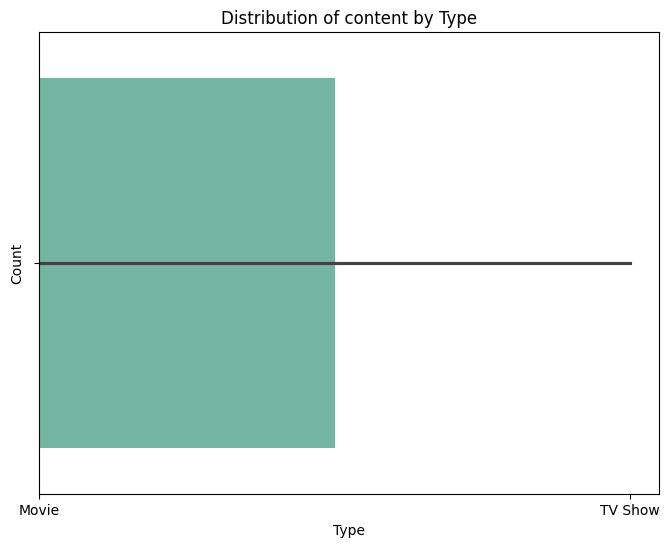

In [13]:
# Plot the distribution
plt.figure(figsize=(8, 6))
sns.barplot(x=type_counts.index,palette='Set2')
plt.title('Distribution of content by Type')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

B. Most Common Genres

In [16]:
# split the 'listed_in' column and count genres
data['genres']  = data['listed_in'].apply(lambda x: x.split(','))
all_genres = sum(data['genres'], [])
genre_counts = pd.Series(all_genres).value_counts().head(10)

/tmp/ipykernel_13734/309496790.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.values, y=genre_counts.index,palette= 'Set3')


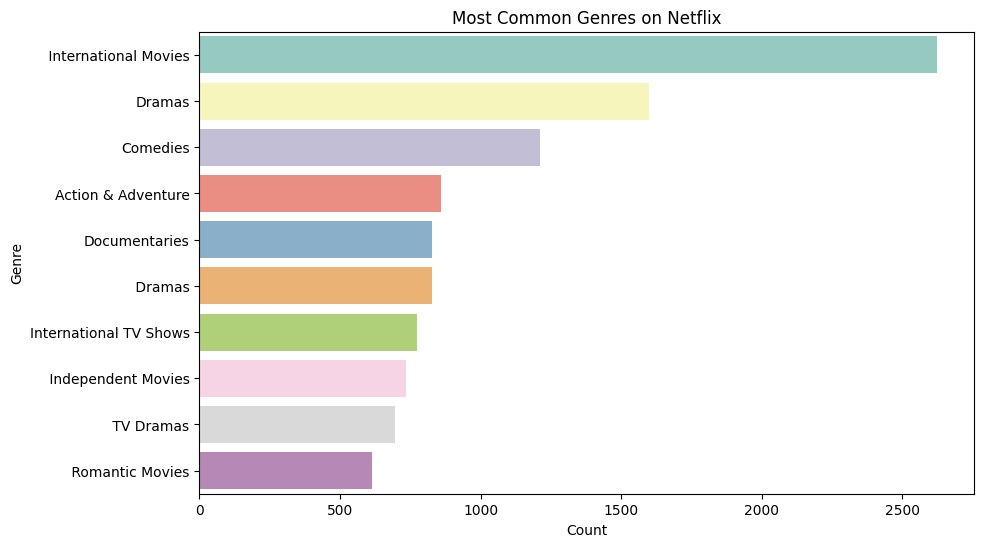

In [17]:
# plot the most common genres
plt.figure(figsize=(10,6))
sns.barplot(x=genre_counts.values, y=genre_counts.index,palette= 'Set3')
plt.title('Most Common Genres on Netflix')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

C. Content Added Over Time

In [19]:
# Extract year and Month from 'data_added'
data['year_added'] = data['data_added'].dt.year
data['month_added'] = data['data_added'].dt.month

/tmp/ipykernel_13734/4090022330.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='year_added', data=data, palette='coolwarm')


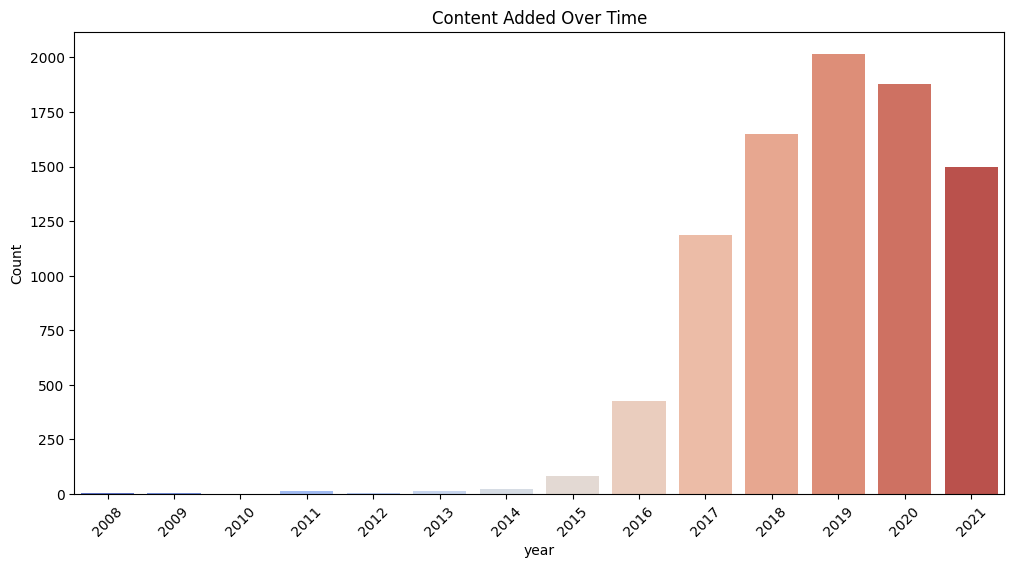

In [20]:
# Plot content added over the years
plt.figure(figsize=(12,6))
sns.countplot(x='year_added', data=data, palette='coolwarm')
plt.title('Content Added Over Time')
plt.xlabel('year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

D. Top 10 Directors with the Most Titles

In [21]:
# count titles by director
top_directors = data['director'].value_counts().head(10)

/tmp/ipykernel_13734/3441111150.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_directors.values, y=top_directors.index, palette= 'Blues_d')


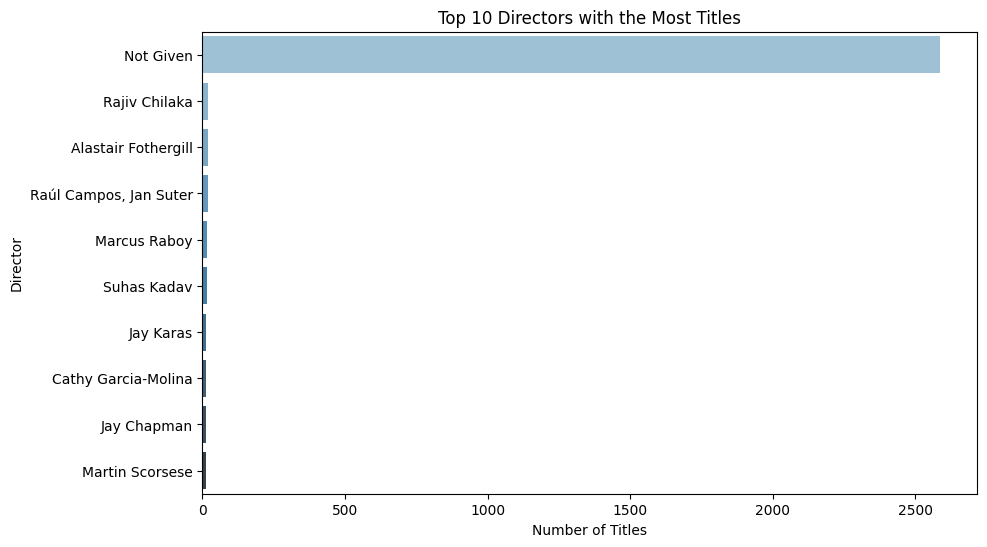

In [23]:
# plot top directors
plt.figure(figsize=(10,6))
sns.barplot(x=top_directors.values, y=top_directors.index, palette= 'Blues_d')
plt.title('Top 10 Directors with the Most Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Director')
plt.show()

E. Word Cloud of Movies Titles

In [25]:
# Generate word cloud
movie_titles = data[data['type'] == 'Movie']['title']
word_cloud = WordCloud(width=800, height=400, background_color='black').generate(' '.join(movie_titles))

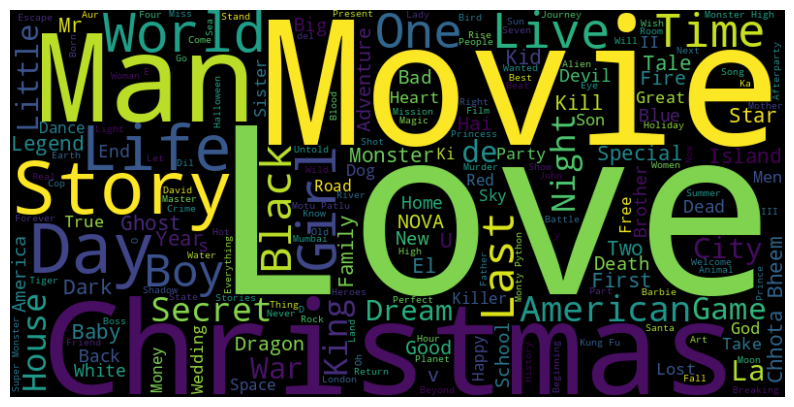

In [27]:
# plot word cloud
plt.figure(figsize=(10, 6))
plt.imshow(word_cloud, interpolation='bilinear')
plt.axis('off')
plt.show()

FEATURE ENGINEERING


Create new features, such as counting the numbeer of genres per movie or extracting the duration in minutes.

let's perform some feature engineering! I'll add new columns to your dataset:

1. duration_in_minutes: Extracts the numerical duration for movies.
2. number_of_seasons: Extracts the numerical number of seasons for TV shows.
3. num_genres: Counts how many genres each title belongs to.


In [28]:
# Extract duration in minutes for movies
data['duration_in_minutes'] = data['duration'].apply(
    lambda x: int(x.split(' ')[0]) if 'min' in x else None
)

# Extract number of seasons for TV Shows
data['number_of_seasons'] = data['duration'].apply(
    lambda x: int(x.split(' ')[0]) if 'Season' in x else None
)

# Count the number of genres per title
data['num_genres'] = data['genres'].apply(len)

# Display the first few rows with the new features
display(data[['title', 'type', 'duration', 'duration_in_minutes', 'number_of_seasons', 'genres', 'num_genres']].head())

,title,type,duration,duration_in_minutes,number_of_seasons,genres,num_genres
0,Dick Johnson Is Dead,Movie,90 min,90.0,NaN,[Documentaries],1
1,Ganglands,TV Show,1 Season,NaN,1.0,"[Crime TV Shows, International TV Shows, TV ...",3
2,Midnight Mass,TV Show,1 Season,NaN,1.0,"[TV Dramas, TV Horror, TV Mysteries]",3
3,Confessions of an Invisible Girl,Movie,91 min,91.0,NaN,"[Children & Family Movies, Comedies]",2
4,Sankofa,Movie,125 min,125.0,NaN,"[Dramas, Independent Movies, International M...",3


The feature engineering step has been successfully completed. You can now see the first few rows of your DataFrame with the newly created columns: duration_in_minutes for movies, number_of_seasons for TV shows, and num_genres which indicates how many genres each title is listed under.

### **A. Content-Based Recommendation System**

To build a recommendation system, we'll leverage the cleaned and processed data. A content-based approach will recommend items similar to ones a user has liked, based on their features (e.g., genres, director, cast, description).

**Steps:**
1.  **Combine Features**: Create a single string of relevant features for each title.
2.  **Vectorize Features**: Convert these text features into numerical vectors using TF-IDF.
3.  **Calculate Similarity**: Compute the cosine similarity matrix between all titles.
4.  **Generate Recommendations**: Create a function to suggest similar titles based on a given title.

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Combine relevant text features into a single string
# We'll use 'listed_in' (genres), 'director', and 'type'
# Fill any NaN values with an empty string to avoid errors
data['combined_features'] = data['listed_in'].fillna('') + ' ' + \
                            data['director'].fillna('') + ' ' + \
                            data['type'].fillna('')

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(stop_words='english')

# Fit and transform the combined features
tfidf_matrix = tfidf_vectorizer.fit_transform(data['combined_features'])

print("TF-IDF matrix shape:", tfidf_matrix.shape)


TF-IDF matrix shape: (8790, 6472)


In [30]:
# Calculate the cosine similarity matrix
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print("Cosine similarity matrix shape:", cosine_sim.shape)

# Create a Series of titles for easy lookup
titles = pd.Series(data.index, index=data['title']).drop_duplicates()

def get_recommendations(title, cosine_sim=cosine_sim, data=data, titles=titles):
    # Get the index of the movie that matches the title
    idx = titles[title]

    # Get the pairwise similarity scores of all movies with that movie
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Sort the movies based on the similarity scores
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get the scores of the 10 most similar movies (excluding itself)
    sim_scores = sim_scores[1:11]

    # Get the movie indices
    movie_indices = [i[0] for i in sim_scores]

    # Return the top 10 most similar movies
    return data['title'].iloc[movie_indices]

# Example of recommendations
print("\nRecommendations for 'Sankofa':")
display(get_recommendations('Sankofa'))

print("\nRecommendations for 'Midnight Mass':")
display(get_recommendations('Midnight Mass'))


Cosine similarity matrix shape: (8790, 8790)

Recommendations for 'Sankofa':


,title
1683,Residue
7807,Adhugo
8413,Dare to Be Wild
7890,Yeh Hai Bakrapur
8707,The Darkest Dawn
8533,Lady-Like
8763,"Twisted Trunk, Big Fat Body"
2527,Mallesham
264,Seven (Telugu)
6675,Last Summer



Recommendations for 'Midnight Mass':


,title
6619,Brand New Cherry Flavor
7046,The Haunting of Bly Manor
7076,Ratched
7910,The Haunting of Hill House
7962,The Originals
8093,The Mist
8545,Lost Girl
8610,Penny Dreadful
3677,Before I Wake
3777,Gerald's Game


### Interactive Content Type Distribution

In [33]:
fig_type_dist = px.bar(
    type_counts.reset_index(),
    x='type',
    y='count',
    title='Interactive Distribution of Content by Type',
    labels={'type': 'Content Type', 'count': 'Count'},
    color='type',
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig_type_dist.update_layout(xaxis_title='Type', yaxis_title='Count')
fig_type_dist.show()